In [25]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

In [26]:
prophet = pd.read_csv("../data/processed/forecast_prophet.csv")

lstm = pd.read_csv("../data/processed/forecast_lstm.csv")

In [27]:
print(prophet.columns)

print(lstm.columns)

prophet.head()

Index(['ds', 'trend', 'yhat_lower', 'yhat_upper', 'trend_lower', 'trend_upper',
       'additive_terms', 'additive_terms_lower', 'additive_terms_upper',
       'weekly', 'weekly_lower', 'weekly_upper', 'yearly', 'yearly_lower',
       'yearly_upper', 'multiplicative_terms', 'multiplicative_terms_lower',
       'multiplicative_terms_upper', 'yhat'],
      dtype='object')
Index(['Actual', 'Prediction'], dtype='object')


,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,weekly,weekly_lower,weekly_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
0,2009-12-01,22863.888278,38462.156672,64069.824459,22863.888278,22863.888278,28234.300481,28234.300481,28234.300481,6625.862082,6625.862082,6625.862082,21608.438398,21608.438398,21608.438398,0.0,0.0,0.0,51098.188759
1,2009-12-02,22867.399377,33356.202642,60083.979763,22867.399377,22867.399377,24686.820475,24686.820475,24686.820475,3767.379718,3767.379718,3767.379718,20919.440756,20919.440756,20919.440756,0.0,0.0,0.0,47554.219851
2,2009-12-03,22870.910475,40331.610532,66966.630821,22870.910475,22870.910475,30631.027344,30631.027344,30631.027344,10563.955785,10563.955785,10563.955785,20067.071559,20067.071559,20067.071559,0.0,0.0,0.0,53501.937819
3,2009-12-04,22874.421574,29798.450051,55646.094076,22874.421574,22874.421574,20099.227595,20099.227595,20099.227595,1047.959127,1047.959127,1047.959127,19051.268468,19051.268468,19051.268468,0.0,0.0,0.0,42973.649169
4,2009-12-05,22877.932672,5190.228277,30183.387644,22877.932672,22877.932672,-4118.405556,-4118.405556,-4118.405556,-21993.077025,-21993.077025,-21993.077025,17874.671469,17874.671469,17874.671469,0.0,0.0,0.0,18759.527116


In [28]:
prophet_pred = prophet["yhat"].tail(len(lstm)).reset_index(drop=True)

lstm_pred = lstm["Prediction"].reset_index(drop=True)

actual = lstm["Actual"].reset_index(drop=True)

dates = prophet["ds"].tail(len(lstm)).reset_index(drop=True)

In [29]:
hybrid_pred = (prophet_pred + lstm_pred) / 2

hybrid_pred.head()

0    19288.829505
1    28316.051310
2    32174.072641
3    33467.180962
4    31939.988981
dtype: float64

In [30]:
mae = mean_absolute_error(actual, hybrid_pred)

rmse = np.sqrt(
    mean_squared_error(actual, hybrid_pred)
)

mask = actual != 0

mape = np.mean(
    np.abs(
        (actual[mask] - hybrid_pred[mask]) /
        actual[mask]
    )
) * 100

print("MAE :", mae)
print("RMSE:", rmse)
print("MAPE:", mape)

MAE : 12901.987603808277
RMSE: 16897.048239784952
MAPE: 24.43228024125457


In [31]:
prophet_mae = mean_absolute_error(actual, prophet_pred)

lstm_mae = mean_absolute_error(actual, lstm_pred)

comparison = pd.DataFrame({

    "Model":[
        "Prophet",
        "LSTM",
        "Hybrid"
    ],

    "MAE":[
        prophet_mae,
        lstm_mae,
        mae
    ]

})

comparison

,Model,MAE
0,Prophet,10181.433505
1,LSTM,21414.250754
2,Hybrid,12901.987604


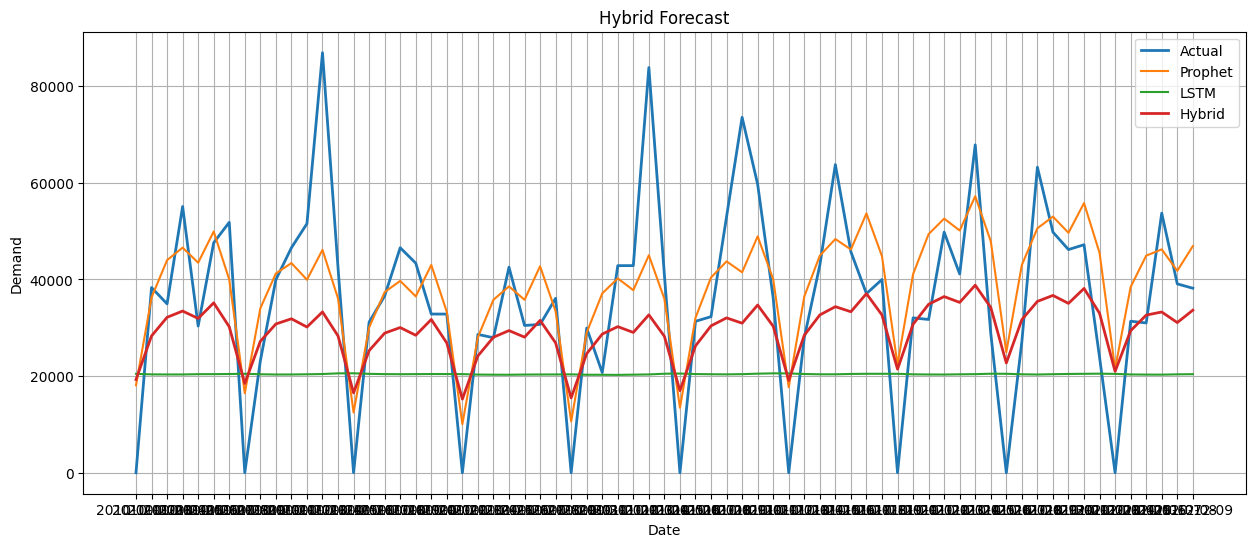

In [32]:
plt.figure(figsize=(15,6))

plt.plot(
    dates,
    actual,
    label="Actual",
    linewidth=2
)

plt.plot(
    dates,
    prophet_pred,
    label="Prophet"
)

plt.plot(
    dates,
    lstm_pred,
    label="LSTM"
)

plt.plot(
    dates,
    hybrid_pred,
    label="Hybrid",
    linewidth=2
)

plt.title("Hybrid Forecast")

plt.xlabel("Date")

plt.ylabel("Demand")

plt.legend()

plt.grid(True)

plt.show()

In [33]:
hybrid_df = pd.DataFrame({

    "ds": dates,

    "Actual": actual,

    "Prophet": prophet_pred,

    "LSTM": lstm_pred,

    "Hybrid": hybrid_pred

})

hybrid_df.head()

,ds,Actual,Prophet,LSTM,Hybrid
0,2010-10-02,0.000,18104.507010,20473.152,19288.829505
1,2010-10-03,38335.520,36274.838621,20357.264,28316.051310
2,2010-10-04,34956.560,44007.237282,20340.908,32174.072641
3,2010-10-05,55108.910,46593.974924,20340.387,33467.180962
4,2010-10-06,30355.012,43479.344961,20400.633,31939.988981


In [34]:
hybrid_df.to_csv(
    "../data/processed/hybrid_forecast.csv",
    index=False
)

print("Hybrid Forecast Saved Successfully!")

Hybrid Forecast Saved Successfully!


In [35]:
try:

    import mlflow

    mlflow.set_experiment("RetailPulse_Forecasting")

    with mlflow.start_run():

        mlflow.log_metric("Hybrid_MAE", mae)

        mlflow.log_metric("Hybrid_RMSE", rmse)

        mlflow.log_metric("Hybrid_MAPE", mape)

        mlflow.log_artifact(
            "../data/processed/hybrid_forecast.csv"
        )

    print("MLflow Logging Completed")

except:

    print("MLflow Not Installed - Skipped")

MLflow Logging Completed
